In [9]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 297
sigma = 0.226
r = 0.04      # risk-free rate (annual) - NEW: replaces mu for prices
n_days = 252
n_paths = 1000
dt = 1/252

In [14]:
def simulate_gbm_risk_neutral(S0, r, sigma, n_days, n_paths, dt=1/252, seed=None):
    if seed is not None:
        np.random.seed(seed)

    Z = np.random.standard_normal((n_paths, n_days))
    daily_log_returns = (r - sigma**2 / 2) * dt + sigma * np.sqrt(dt) * Z
    cumulative = np.cumsum(daily_log_returns, axis=1)
    price_paths = S0 * np.exp(cumulative)

    return price_paths

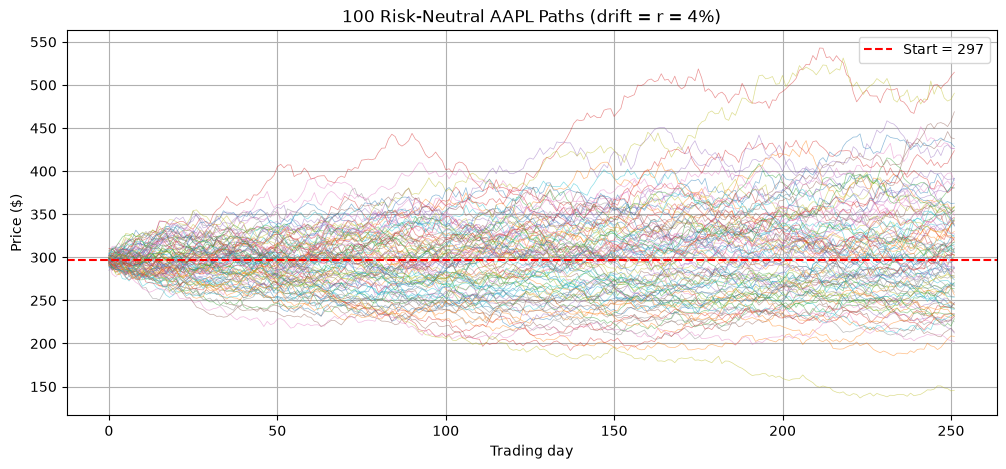

In [15]:
paths_rn = simulate_gbm_risk_neutral(S0, r, sigma, n_days, n_paths, seed=42)

plt.figure(figsize=(12, 5))
plt.plot(paths_rn[:100].T, linewidth=0.5, alpha=0.5)
plt.axhline(S0, color="red", linestyle="--", label=f"Start = {S0}")
plt.title("100 Risk-Neutral AAPL Paths (drift = r = 4%)")
plt.xlabel("Trading day")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()
